In [103]:
import scipy.constants as ctes
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [104]:
N_e=10000
temperature = 1e3
MxB = stats.maxwell(scale = np.sqrt(ctes.Boltzmann*temperature/ctes.electron_mass))
x = np.linspace(MxB.ppf(0.01), MxB.ppf(0.99), 1000)

In [105]:
dt = 1e-11 # s
t_f = 3e-9 # s
U = 300 # V
d = 0.01 # m
h_filamento = 0.004 # m

a = (U/d)*ctes.elementary_charge/ctes.electron_mass

In [106]:
a0_i = np.array(list(zip(np.ones(N_e)*a,np.zeros(N_e))))
print(a0_i)

[[5.27646003e+15 0.00000000e+00]
 [5.27646003e+15 0.00000000e+00]
 [5.27646003e+15 0.00000000e+00]
 ...
 [5.27646003e+15 0.00000000e+00]
 [5.27646003e+15 0.00000000e+00]
 [5.27646003e+15 0.00000000e+00]]


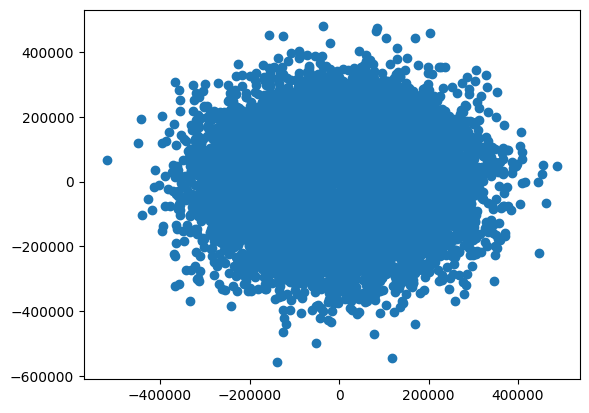

In [107]:
angles = stats.uniform.rvs(size = N_e, scale = 2*np.pi)
v_modules = MxB.rvs(size=N_e)

v0x_i = v_modules*np.cos(angles)
v0y_i = v_modules*np.sin(angles)
v0_i=np.array(list(zip( v0x_i, v0y_i)))
plt.scatter(v0x_i, v0y_i)

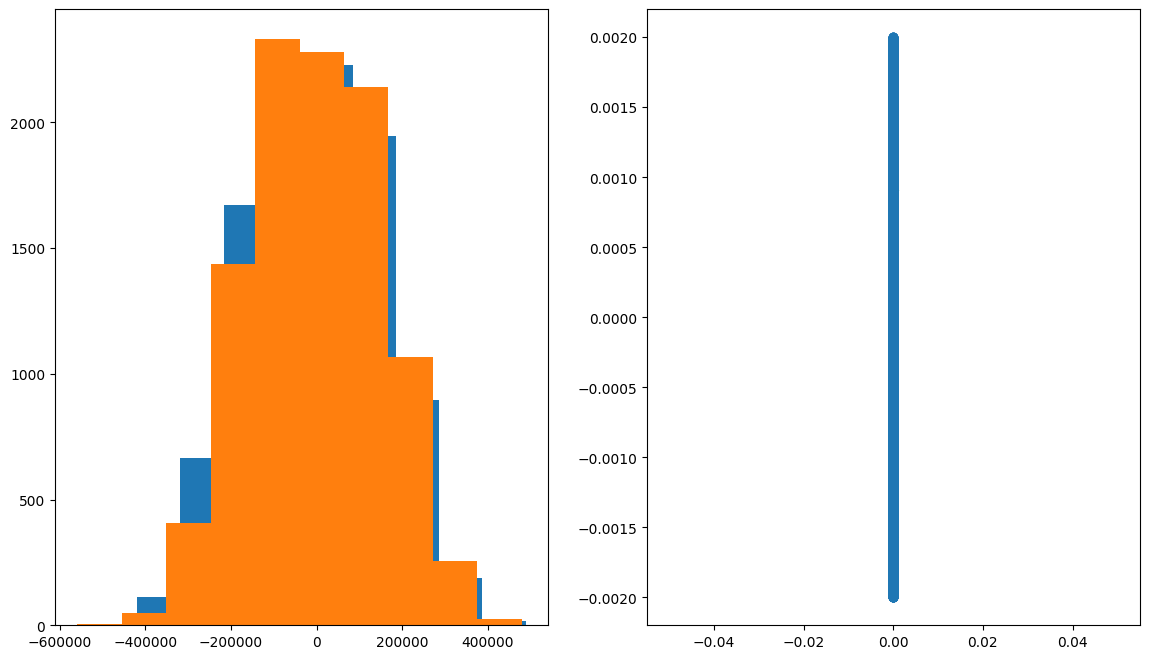

In [108]:
x0_i = np.zeros(N_e)
y0_i = stats.uniform.rvs(size=N_e, loc = -h_filamento/2, scale = h_filamento)

r0_i=np.array(list(zip(x0_i, y0_i)))


fig, ax = plt.subplots(1,2, figsize = (14,8))

ax[0].hist(v0x_i)
ax[0].hist(v0y_i)

ax[1].quiver(x0_i, y0_i, v0x_i, v0y_i, angles='xy', color='green', width=0.001)
ax[1].scatter(x0_i, y0_i)


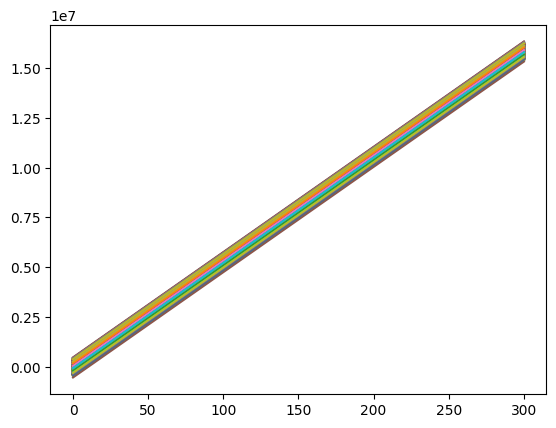

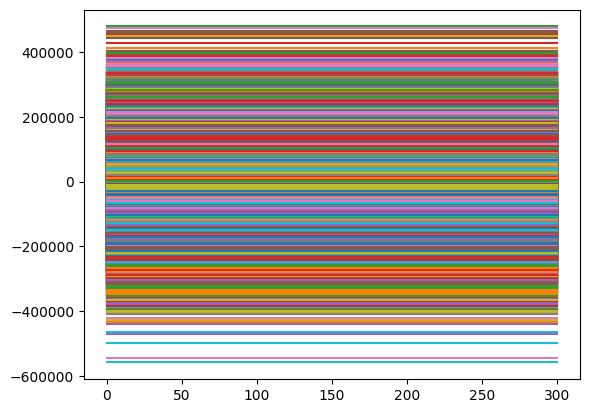

In [109]:
vx = np.array([v0x_i])

for i in range(1, int(t_f//dt+1)):
    
    vx = np.concatenate((vx, [v0x_i+a*dt*i]), axis=0)
    
vx = pd.DataFrame(vx)

vy = pd.DataFrame([v0y_i]*int(t_f//dt+1))

vx.plot()
plt.legend('', frameon=False)
vy.plot()
plt.legend('', frameon=False)

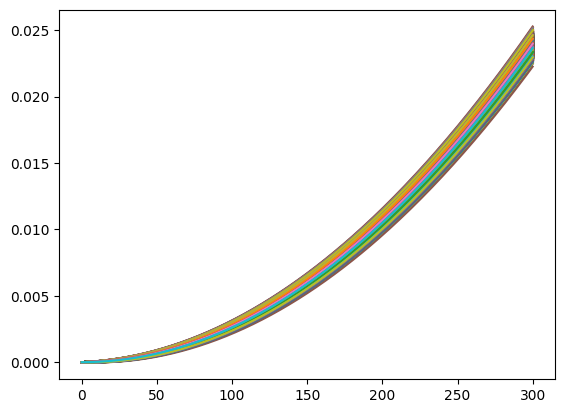

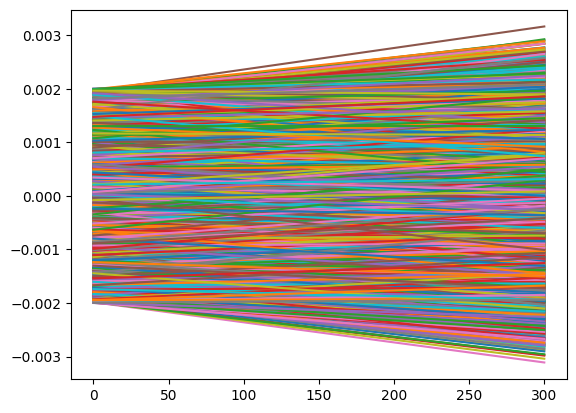

In [ ]:
x = np.array([x0_i])

for i in range(1, int(t_f//dt+1)):
    
    x = np.concatenate((x, [x[i-1]+vx.iloc[i]*dt]), axis=0)
    
x = pd.DataFrame(x)

y = np.array([y0_i])

for i in range(1, int(t_f//dt+1)):
    
    y = np.concatenate((y, [y[i-1]+vy.iloc[i]*dt]), axis=0)
    
y = pd.DataFrame(y)

x.plot()
plt.legend('', frameon=False)
y.plot()
plt.legend('', frameon=False)

(array([   5.,  112.,  666., 1670., 2277., 2228., 1945.,  894.,  187.,
          16.]),
 array([15309787.33659774, 15410556.55348775, 15511325.77037776,
        15612094.98726777, 15712864.20415777, 15813633.42104778,
        15914402.63793779, 16015171.8548278 , 16115941.0717178 ,
        16216710.28860781, 16317479.50549782]),
 <BarContainer object of 10 artists>)

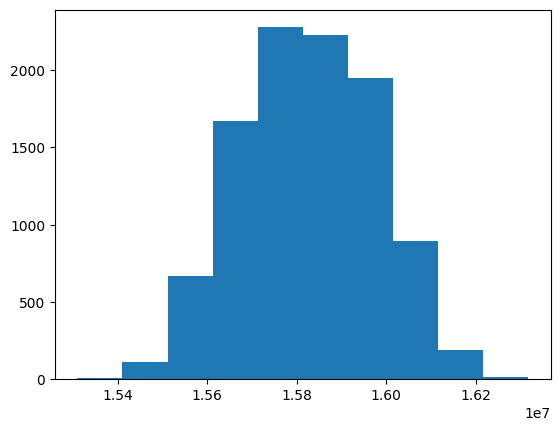

In [112]:
plt.hist(vx.loc[300])